In [4]:
print(df.columns.tolist())

['customer_id', 'age', 'gender', 'region', 'primary_device', 'traffic_source', 'category_focus', 'annual_income_inr', 'membership_years', 'premium_member', 'app_sessions_per_month', 'avg_session_minutes', 'pages_per_session', 'discount_sensitivity_1to7', 'review_score_avg_1to10', 'delivery_delay_days', 'support_contacts_12m', 'purchases_12m', 'average_order_value_inr', 'annual_revenue_inr', 'predicted_churn_risk', 'estimated_clv_inr', 'value_segment', 'churn_flag']


Dataset Shape: (1200, 22)

Columns:
['customer_id', 'age', 'gender', 'region', 'primary_device', 'traffic_source', 'category_focus', 'annual_income_inr', 'membership_years', 'premium_member', 'app_sessions_per_month', 'avg_session_minutes', 'pages_per_session', 'discount_sensitivity_1to7', 'review_score_avg_1to10', 'delivery_delay_days', 'support_contacts_12m', 'purchases_12m', 'average_order_value_inr', 'annual_revenue_inr', 'predicted_churn_risk', 'estimated_clv_inr']

First 5 Rows
  customer_id  age  gender region primary_device traffic_source  \
0       C0001   39    Male   West        Desktop          Email   
1       C0002   26    Male  South            iOS         Direct   
2       C0003   51    Male   East        Android         Social   
3       C0004   34    Male  North        Android          Email   
4       C0005   46  Female  Metro        Android         Social   

  category_focus  annual_income_inr  membership_years  premium_member  ...  \
0         Beauty             4

/tmp/ipykernel_840/1937811536.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = df.groupby("value_segment").agg({


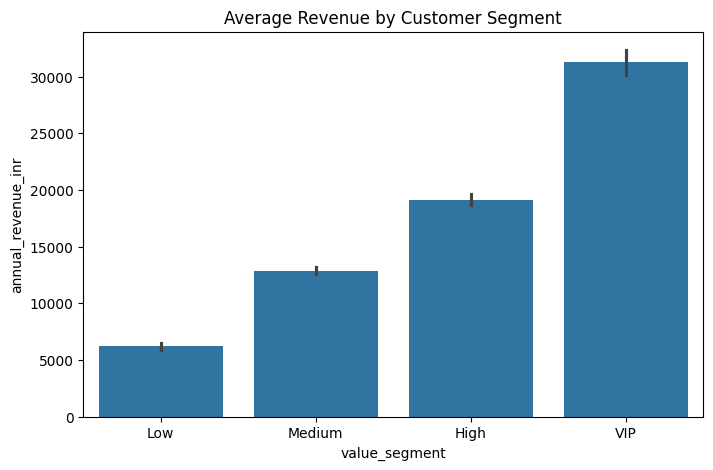

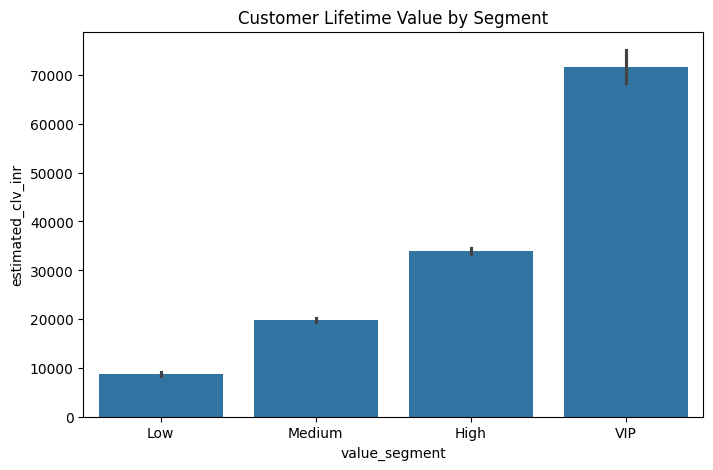

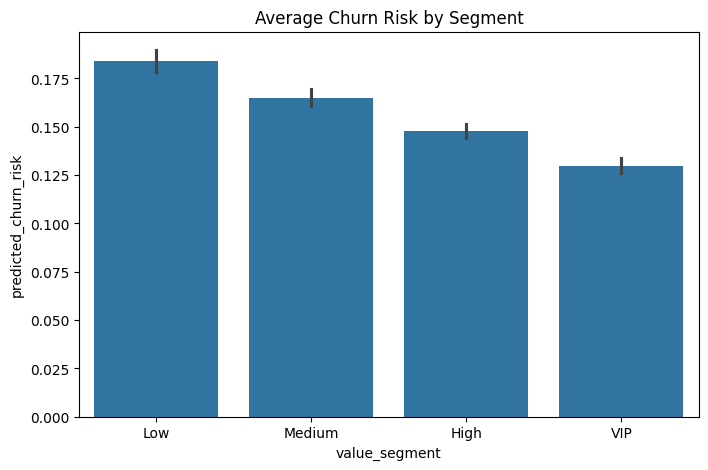

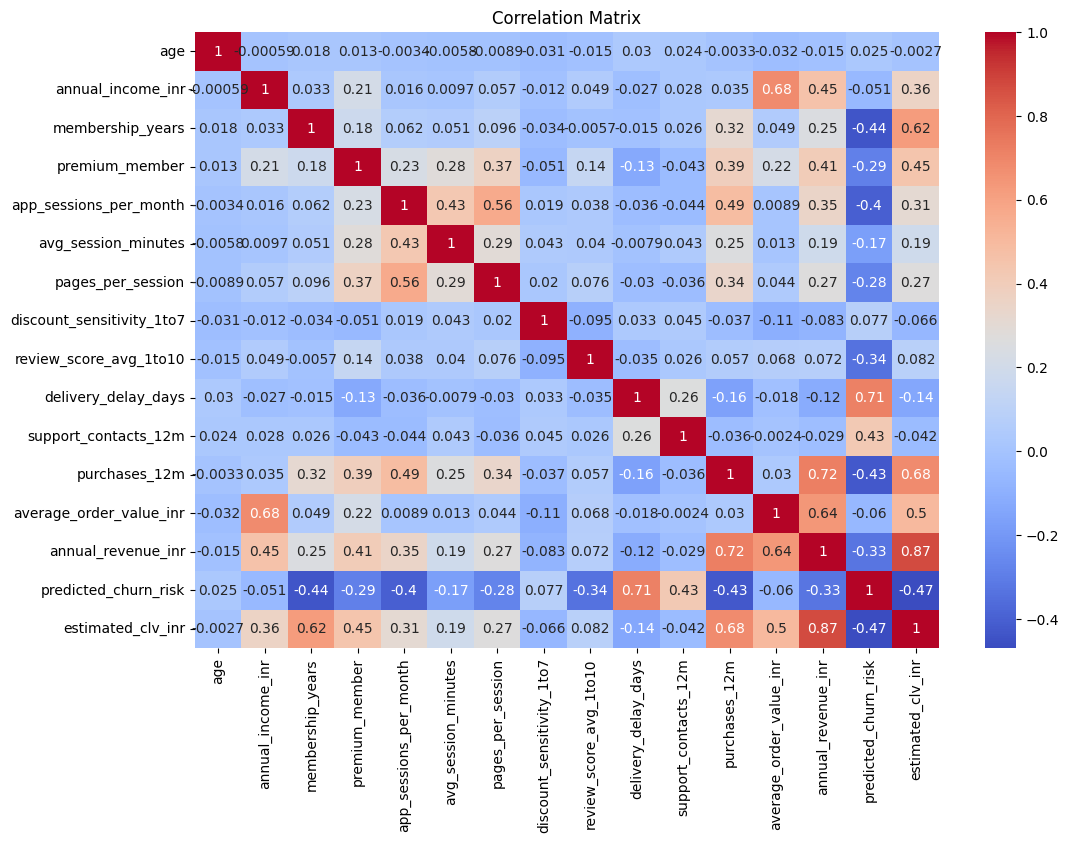


Revenue Driver Coefficients
                  Variable  Coefficient
5            purchases_12m  2083.572196
4        pages_per_session    12.311746
6  average_order_value_inr     8.051684
3      avg_session_minutes     4.589352
0        annual_income_inr     0.000787
2   app_sessions_per_month    -5.229360
1         membership_years   -17.165107


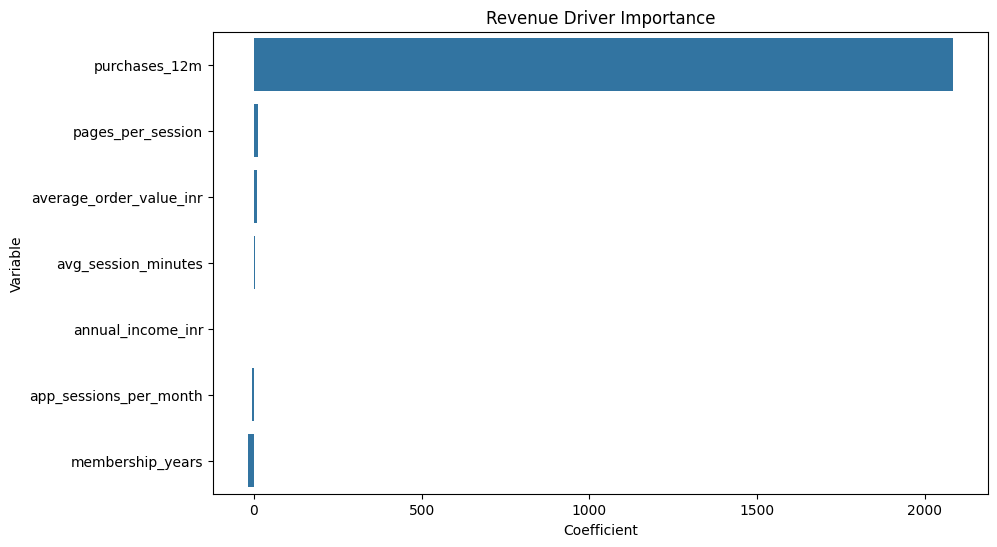


Churn Distribution
churn_flag
0    606
1    594
Name: count, dtype: int64

Logistic Regression Accuracy: 0.8722

Churn Driver Coefficients
                 Variable  Coefficient
2     delivery_delay_days     1.483535
3    support_contacts_12m     0.962010
1     avg_session_minutes    -0.054471
0  app_sessions_per_month    -0.164042
5           purchases_12m    -0.169526
4  review_score_avg_1to10    -1.128042


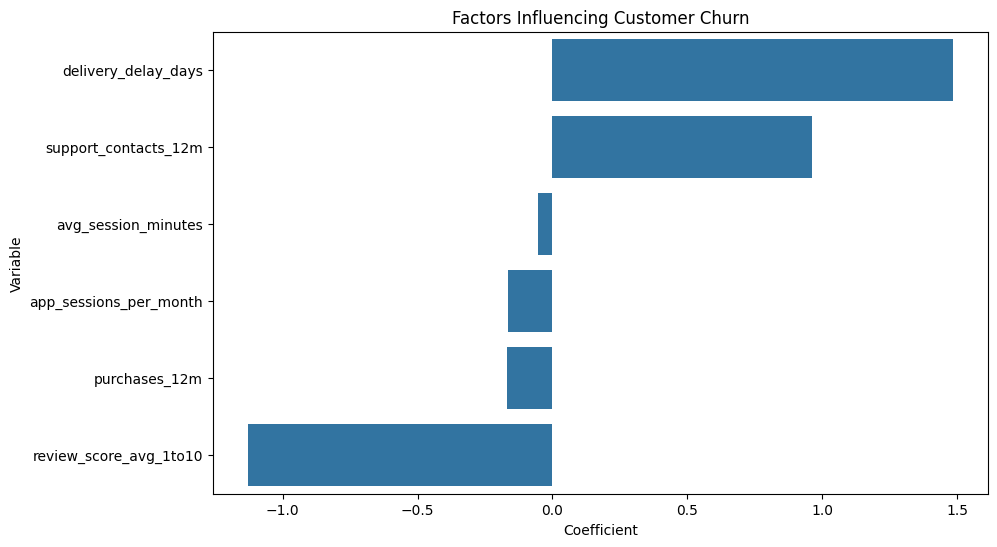


High Value Customers At Risk
   customer_id  age  gender region primary_device traffic_source  \
12       C0013   39  Female  South            iOS        Organic   
19       C0020   18    Male  Metro        Android        Organic   
29       C0030   40  Female  South        Android          Email   
31       C0032   22  Female   West        Android        Organic   
37       C0038   47    Male   East            iOS       Referral   

   category_focus  annual_income_inr  membership_years  premium_member  ...  \
12         Beauty             965331               1.0               1  ...   
19         Beauty             723082               2.4               1  ...   
29           Home             250000               0.9               1  ...   
31         Sports             628464               1.6               1  ...   
37        Fashion             675962               2.5               1  ...   

    review_score_avg_1to10  delivery_delay_days  support_contacts_12m  \
12           

In [5]:
# ==========================================================
# CUSTOMER VALUE & ENGAGEMENT ANALYSIS
# SEGMENT-SPECIFIC RECOVERY PLAN
# ==========================================================

# -------------------------------
# IMPORT LIBRARIES
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# -------------------------------
# LOAD DATA
# -------------------------------

df = pd.read_csv("A_Customer_Value_Engagement.csv")

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows")
print(df.head())

# -------------------------------
# DATA UNDERSTANDING
# -------------------------------

print("\nDataset Info")
print(df.info())

print("\nSummary Statistics")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

# ==========================================================
# CUSTOMER SEGMENTATION
# ==========================================================

df["value_segment"] = pd.qcut(
    df["estimated_clv_inr"],
    q=4,
    labels=["Low", "Medium", "High", "VIP"]
)

print("\nSegment Distribution")
print(df["value_segment"].value_counts())

# -------------------------------
# SEGMENT SUMMARY
# -------------------------------

segment_summary = df.groupby("value_segment").agg({
    "annual_revenue_inr":"mean",
    "estimated_clv_inr":"mean",
    "predicted_churn_risk":"mean",
    "purchases_12m":"mean"
}).round(2)

print("\nSegment Summary")
print(segment_summary)

# ==========================================================
# VISUALIZATION 1
# REVENUE BY SEGMENT
# ==========================================================

plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="value_segment",
    y="annual_revenue_inr"
)
plt.title("Average Revenue by Customer Segment")
plt.show()

# ==========================================================
# VISUALIZATION 2
# CLV BY SEGMENT
# ==========================================================

plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="value_segment",
    y="estimated_clv_inr"
)
plt.title("Customer Lifetime Value by Segment")
plt.show()

# ==========================================================
# VISUALIZATION 3
# CHURN RISK BY SEGMENT
# ==========================================================

plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="value_segment",
    y="predicted_churn_risk"
)
plt.title("Average Churn Risk by Segment")
plt.show()

# ==========================================================
# VISUALIZATION 4
# CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# ==========================================================
# LINEAR REGRESSION
# REVENUE DRIVERS
# ==========================================================

features = [
    "annual_income_inr",
    "membership_years",
    "app_sessions_per_month",
    "avg_session_minutes",
    "pages_per_session",
    "purchases_12m",
    "average_order_value_inr"
]

X = df[features]
y = df["annual_revenue_inr"]

lr = LinearRegression()

lr.fit(X, y)

coefficients = pd.DataFrame({
    "Variable": features,
    "Coefficient": lr.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print("\nRevenue Driver Coefficients")
print(coefficients)

# ==========================================================
# VISUALIZATION 5
# REVENUE DRIVER IMPORTANCE
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Variable"
)

plt.title("Revenue Driver Importance")
plt.show()

# ==========================================================
# LOGISTIC REGRESSION
# CHURN PREDICTION (FIXED)
# ==========================================================

cutoff = df["predicted_churn_risk"].median()

df["churn_flag"] = np.where(
    df["predicted_churn_risk"] > cutoff,
    1,
    0
)

print("\nChurn Distribution")
print(df["churn_flag"].value_counts())

features = [
    "app_sessions_per_month",
    "avg_session_minutes",
    "delivery_delay_days",
    "support_contacts_12m",
    "review_score_avg_1to10",
    "purchases_12m"
]

X = df[features]
y = df["churn_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train,
    y_train
)

pred = log_model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    pred
)

print("\nLogistic Regression Accuracy:", round(accuracy,4))

# ==========================================================
# CHURN DRIVER ANALYSIS
# ==========================================================

churn_coef = pd.DataFrame({
    "Variable": features,
    "Coefficient": log_model.coef_[0]
})

churn_coef = churn_coef.sort_values(
    by="Coefficient",
    ascending=False
)

print("\nChurn Driver Coefficients")
print(churn_coef)

# ==========================================================
# VISUALIZATION 6
# CHURN DRIVER IMPORTANCE
# ==========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=churn_coef,
    x="Coefficient",
    y="Variable"
)

plt.title("Factors Influencing Customer Churn")
plt.show()

# ==========================================================
# HIGH VALUE CUSTOMERS AT RISK
# ==========================================================

critical_customers = df[
    (df["value_segment"].isin(["High","VIP"])) &
    (df["predicted_churn_risk"] > cutoff)
]

print("\nHigh Value Customers At Risk")
print(critical_customers.head())

# ==========================================================
# FINAL INTERPRETATION
# ==========================================================

print("""
BUSINESS INSIGHTS

1. VIP customers generate the highest revenue and CLV.

2. Purchase frequency and average order value are major
   revenue drivers.

3. Churn is influenced by engagement, reviews,
   support contacts and delivery experience.

4. High-value customers with high churn risk should
   receive immediate retention efforts.

RECOMMENDATIONS

VIP:
- Loyalty rewards
- Premium support

High:
- Cross-selling
- Membership upgrades

Medium:
- Personalized promotions

Low:
- Automated campaigns

LIMITATION

Analysis is based on historical customer behavior
and predicted churn risk.
""")

## Customer Value & Engagement Dashboard

This dashboard provides a consolidated view of key metrics and insights from the customer value and engagement analysis, including segment performance, revenue drivers, and factors influencing churn.

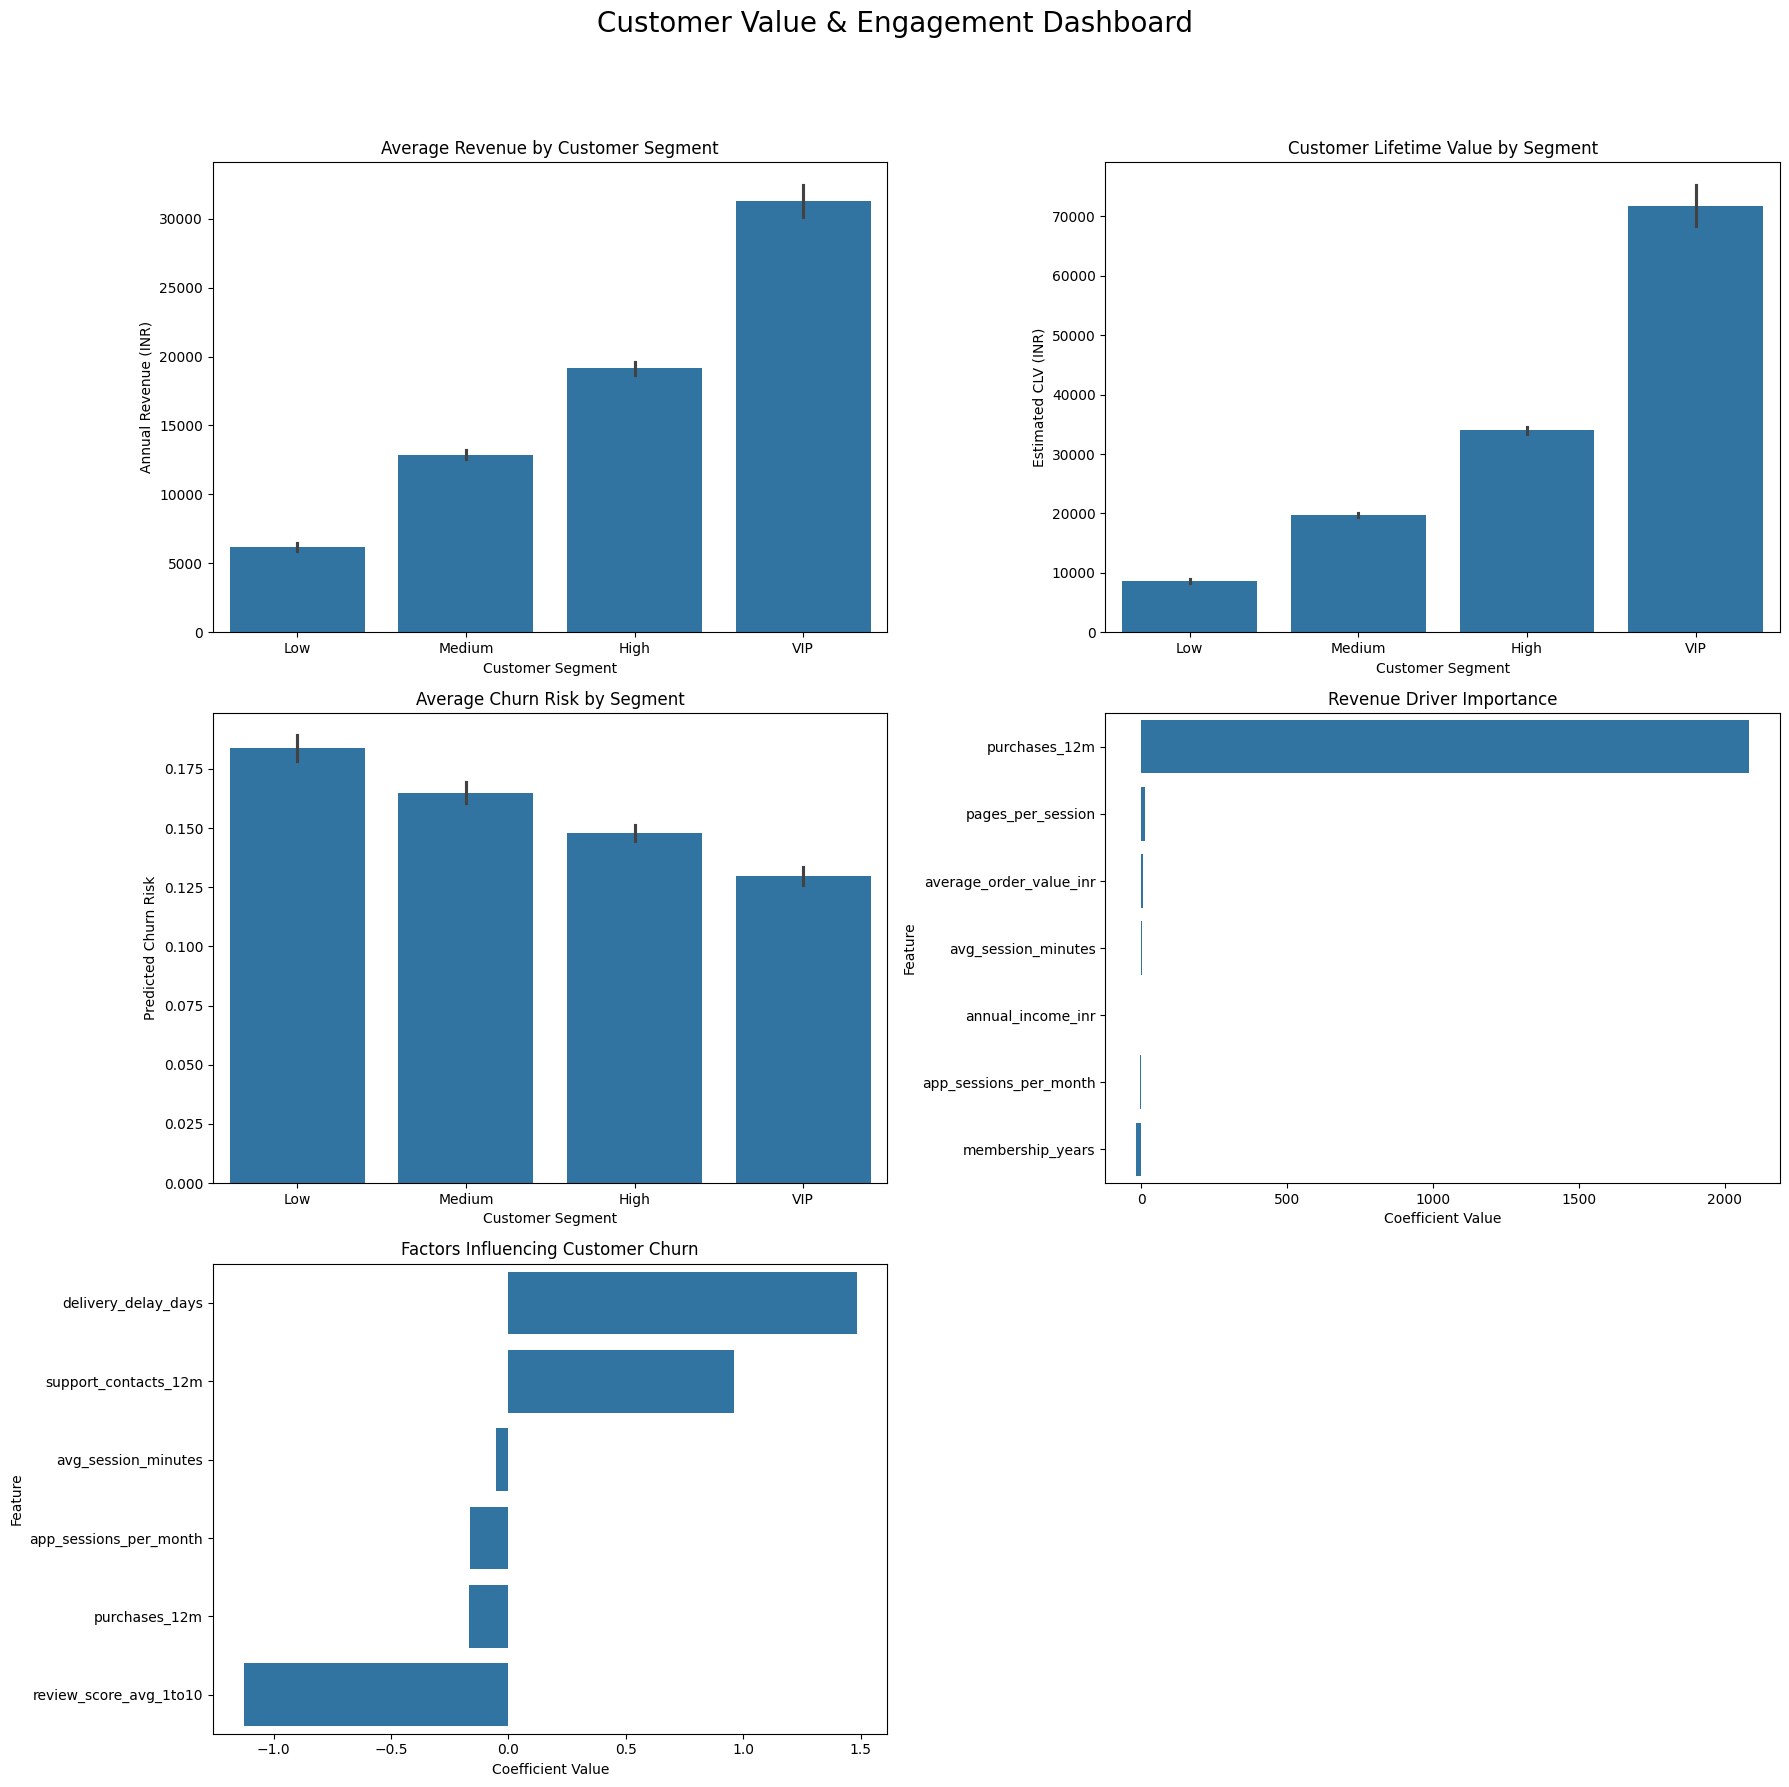

In [6]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 18))
fig.suptitle('Customer Value & Engagement Dashboard', fontsize=20, y=1.02)

# Plot 1: Average Revenue by Customer Segment
sns.barplot(data=df, x="value_segment", y="annual_revenue_inr", ax=axes[0, 0])
axes[0, 0].set_title('Average Revenue by Customer Segment')
axes[0, 0].set_xlabel('Customer Segment')
axes[0, 0].set_ylabel('Annual Revenue (INR)')

# Plot 2: Customer Lifetime Value by Segment
sns.barplot(data=df, x="value_segment", y="estimated_clv_inr", ax=axes[0, 1])
axes[0, 1].set_title('Customer Lifetime Value by Segment')
axes[0, 1].set_xlabel('Customer Segment')
axes[0, 1].set_ylabel('Estimated CLV (INR)')

# Plot 3: Average Churn Risk by Segment
sns.barplot(data=df, x="value_segment", y="predicted_churn_risk", ax=axes[1, 0])
axes[1, 0].set_title('Average Churn Risk by Segment')
axes[1, 0].set_xlabel('Customer Segment')
axes[1, 0].set_ylabel('Predicted Churn Risk')

# Plot 4: Revenue Driver Importance
sns.barplot(data=coefficients, x="Coefficient", y="Variable", ax=axes[1, 1])
axes[1, 1].set_title('Revenue Driver Importance')
axes[1, 1].set_xlabel('Coefficient Value')
axes[1, 1].set_ylabel('Feature')

# Plot 5: Churn Driver Importance
sns.barplot(data=churn_coef, x="Coefficient", y="Variable", ax=axes[2, 0])
axes[2, 0].set_title('Factors Influencing Customer Churn')
axes[2, 0].set_xlabel('Coefficient Value')
axes[2, 0].set_ylabel('Feature')

# Hide the unused subplot (if any, in case of odd number of plots)
if len(axes.flatten()) > 5:
    axes[2, 1].axis('off') # Hiding the last subplot if it's empty

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

# 📈 Customer Value & Engagement Analysis Dashboard 📊

This interactive dashboard presents a holistic view of customer segmentation, revenue drivers, and churn prediction, offering actionable insights for strategic decision-making.

## 🚀 1. Data Overview & Customer Segmentation

We start by loading the dataset and segmenting customers based on their estimated Customer Lifetime Value (CLV). This foundational step helps us understand the distinct characteristics of different customer groups.

In [7]:
print("### Dataset Shape and First Five Rows")
print(f"Dataset Shape: {df.shape}\n")
display(df.head())

print("\n### Segment Distribution")
display(df["value_segment"].value_counts())

print("\n### Segment Summary")
display(segment_summary)

### Dataset Shape and First Five Rows
Dataset Shape: (1200, 24)



,customer_id,age,gender,region,primary_device,traffic_source,category_focus,annual_income_inr,membership_years,premium_member,...,review_score_avg_1to10,delivery_delay_days,support_contacts_12m,purchases_12m,average_order_value_inr,annual_revenue_inr,predicted_churn_risk,estimated_clv_inr,value_segment,churn_flag
0,C0001,39,Male,West,Desktop,Email,Beauty,410288,1.6,1,...,5.7,1,0,6,1596.74,9593.42,0.147,17986.65,Medium,0
1,C0002,26,Male,South,iOS,Direct,Grocery,258573,0.1,0,...,5.0,0,1,8,1586.65,12509.11,0.163,14951.34,Medium,1
2,C0003,51,Male,East,Android,Social,Grocery,412980,6.2,0,...,7.8,1,2,10,1729.06,15849.01,0.098,44831.65,VIP,0
3,C0004,34,Male,North,Android,Email,Sports,268451,1.0,0,...,5.6,5,1,2,1902.79,3846.08,0.256,4807.29,Low,1
4,C0005,46,Female,Metro,Android,Social,Fashion,1200092,2.3,1,...,7.2,2,0,10,2634.08,22880.30,0.120,48202.39,VIP,0



### Segment Distribution


,count
value_segment,
Low,300
Medium,300
High,300
VIP,300



### Segment Summary


,annual_revenue_inr,estimated_clv_inr,predicted_churn_risk,purchases_12m
value_segment,,,,
Low,6213.70,8644.61,0.18,4.58
Medium,12874.90,19741.94,0.16,7.12
High,19143.29,33962.13,0.15,9.17
VIP,31262.45,71686.09,0.13,11.64


**Interpretation of Segmentation:**

- The dataset contains **1200 records** with various customer attributes.
- Customers are evenly divided into **four value segments (Low, Medium, High, VIP)**, each comprising 300 customers.
- The `Segment Summary` table clearly shows a progressive increase in `annual_revenue_inr`, `estimated_clv_inr`, and `purchases_12m` from the Low to VIP segments. This confirms the effectiveness of the CLV-based segmentation.
- Interestingly, `predicted_churn_risk` tends to decrease as customer value increases, suggesting that more valuable customers are generally less likely to churn.

## 📊 2. Key Visualizations: Understanding Customer Behavior

Visualizing the data helps us uncover patterns, correlations, and critical areas for intervention across different customer segments.

### 2.1. Average Revenue by Customer Segment

This visualization highlights the revenue contribution of each customer segment.

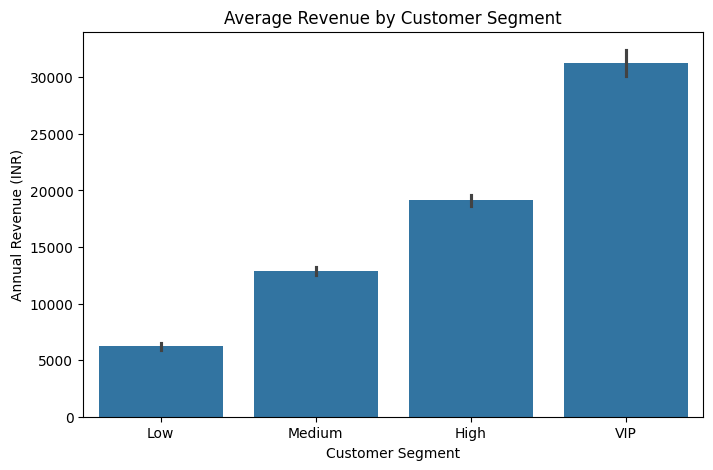

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="value_segment",
    y="annual_revenue_inr"
)
plt.title("Average Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Annual Revenue (INR)")
plt.show()

**Interpretation:**
- **VIP customers generate the highest average annual revenue**, significantly surpassing other segments.
- This trend reinforces the importance of focusing on high-value segments for revenue growth and retention strategies.

### 2.2. Customer Lifetime Value by Segment

Understanding the estimated CLV for each segment underscores their long-term potential.

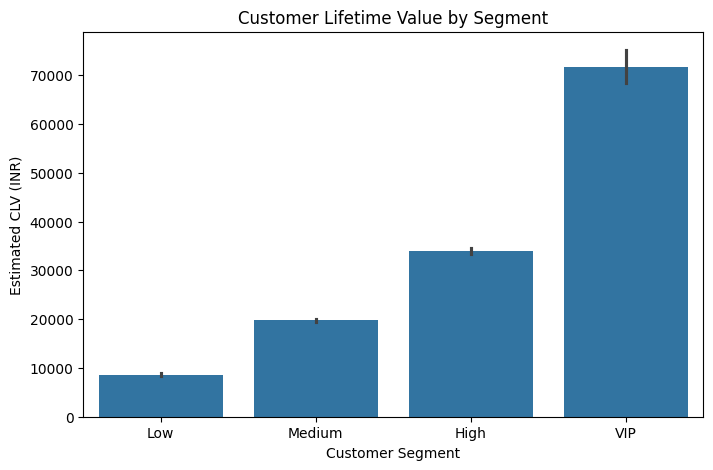

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="value_segment",
    y="estimated_clv_inr"
)
plt.title("Customer Lifetime Value by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Estimated CLV (INR)")
plt.show()

**Interpretation:**
- **Estimated Customer Lifetime Value increases steadily from Low to VIP segments**, with VIPs being the most valuable group over their lifecycle.
- This validates our segmentation strategy and emphasizes that VIP customers promise the highest future profitability.

### 2.3. Average Churn Risk by Segment

This visualization helps identify which segments are most vulnerable to churn.

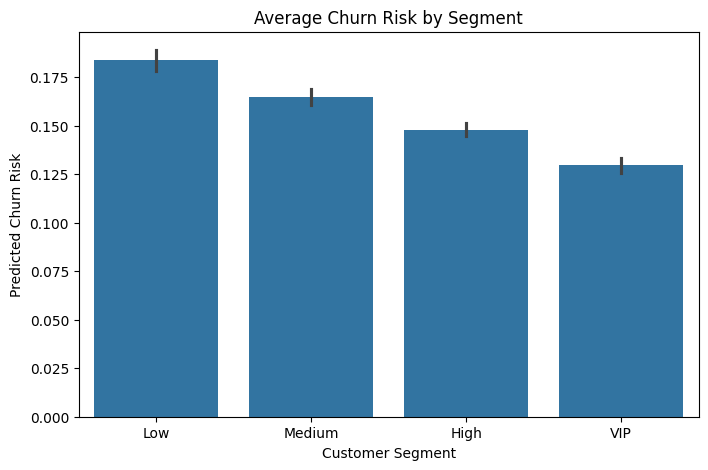

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="value_segment",
    y="predicted_churn_risk"
)
plt.title("Average Churn Risk by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Predicted Churn Risk")
plt.show()

**Interpretation:**
- **Lower value segments (Low and Medium) exhibit higher average churn risk** compared to High and VIP segments.
- This suggests that retention efforts should be strategically targeted, with a focus on understanding and addressing the specific pain points of higher-risk segments, especially if they are valuable.

### 2.4. Correlation Heatmap

Examining the correlations between numerical variables provides insights into their relationships and potential drivers.

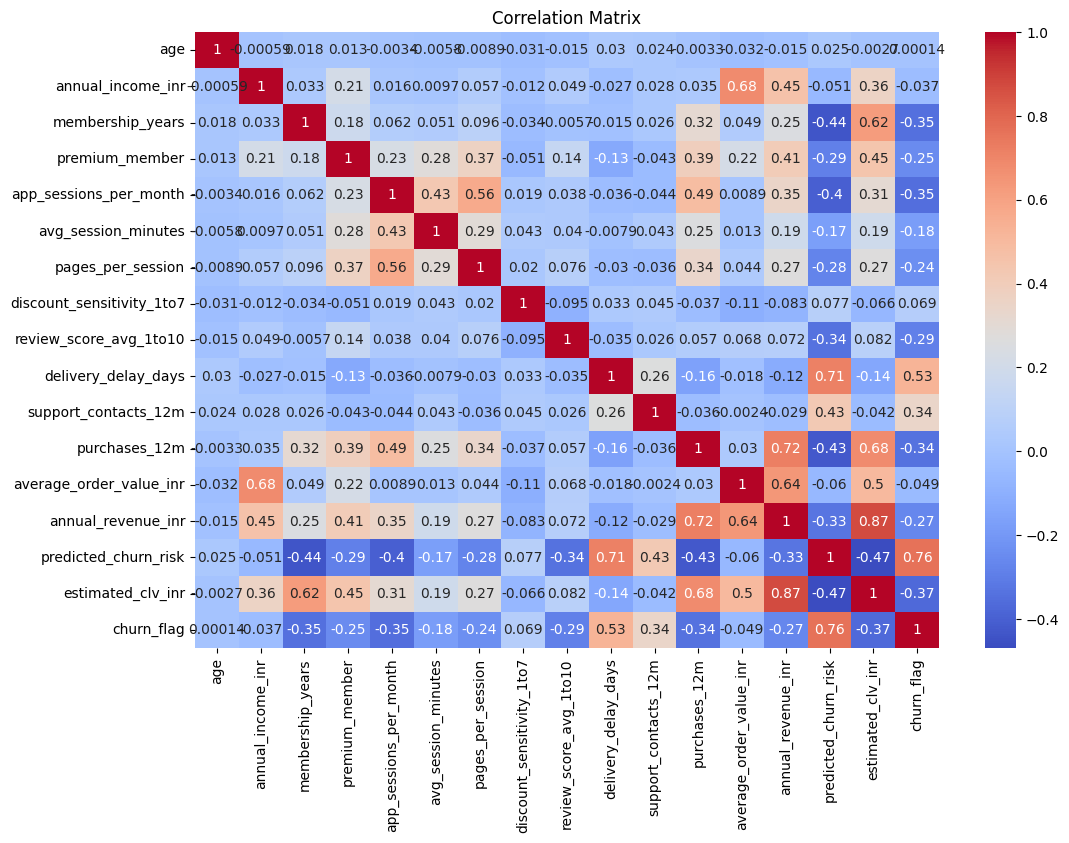

In [11]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

**Interpretation:**
- **Positive correlations (warm colors)** indicate variables that move in the same direction (e.g., higher `purchases_12m` with higher `annual_revenue_inr`).
- **Negative correlations (cool colors)** indicate inverse relationships (e.g., higher `delivery_delay_days` might correlate with lower `review_score_avg_1to10`).
- Strong correlations help identify important business drivers and potential areas for improvement or leverage.

## 📈 3. Predictive Analytics: Revenue & Churn Drivers

We employ Linear Regression to identify factors influencing annual revenue and Logistic Regression to pinpoint drivers of customer churn. This predictive modeling helps us understand 'why' certain behaviors occur.

### 3.1. Revenue Driver Coefficients (Linear Regression)

Understanding which variables positively or negatively impact annual revenue is crucial for growth strategies.

In [12]:
print("### Revenue Driver Coefficients")
display(coefficients)

### Revenue Driver Coefficients


,Variable,Coefficient
5,purchases_12m,2083.572196
4,pages_per_session,12.311746
6,average_order_value_inr,8.051684
3,avg_session_minutes,4.589352
0,annual_income_inr,0.000787
2,app_sessions_per_month,-5.229360
1,membership_years,-17.165107


**Interpretation:**
- **`purchases_12m`** is the strongest positive driver of annual revenue, indicating that higher purchase frequency leads to significantly more revenue.
- `pages_per_session` and `average_order_value_inr` also have positive impacts.
- `membership_years` and `app_sessions_per_month` show slight negative coefficients, which might warrant further investigation into their specific interactions with revenue.

### 3.2. Revenue Driver Importance Visualization

A visual representation of the impact of each feature on annual revenue.

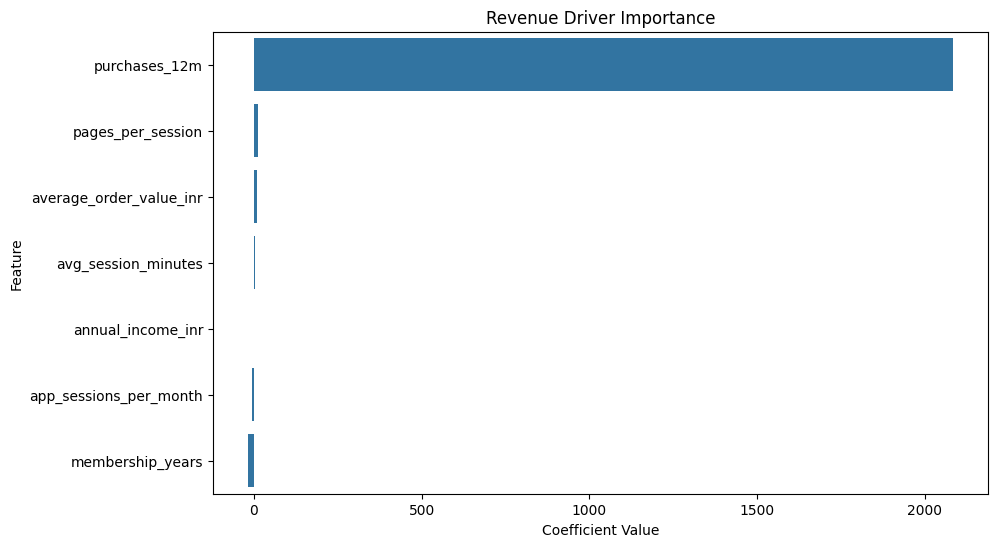

In [13]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Variable"
)
plt.title("Revenue Driver Importance")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

**Interpretation:**
- This bar plot visually confirms that **`purchases_12m` is by far the most influential positive driver** of annual revenue.
- Variables with larger positive coefficients (e.g., `purchases_12m`, `pages_per_session`) should be prioritized in customer growth strategies.

### 3.3. Churn Driver Coefficients (Logistic Regression)

Understanding factors that contribute to churn is essential for developing effective retention strategies. The model achieved an accuracy of approximately **87.22%** in predicting churn.

In [14]:
print(f"### Logistic Regression Accuracy: {round(accuracy,4)}\n")
print("### Churn Driver Coefficients")
display(churn_coef)

### Logistic Regression Accuracy: 0.8722

### Churn Driver Coefficients


,Variable,Coefficient
2,delivery_delay_days,1.483535
3,support_contacts_12m,0.962010
1,avg_session_minutes,-0.054471
0,app_sessions_per_month,-0.164042
5,purchases_12m,-0.169526
4,review_score_avg_1to10,-1.128042


**Interpretation:**
- **Positive coefficients increase churn risk:** `delivery_delay_days` and `support_contacts_12m` are significant positive drivers of churn. This means longer delivery delays and more support contacts increase the likelihood of a customer churning.
- **Negative coefficients reduce churn risk:** `review_score_avg_1to10` has a strong negative coefficient, indicating that higher average review scores significantly reduce churn risk. Other factors like `purchases_12m`, `app_sessions_per_month`, and `avg_session_minutes` also slightly reduce churn risk.

### 3.4. Churn Driver Importance Visualization

Visualizing churn drivers helps quickly grasp which factors are most critical for customer retention.

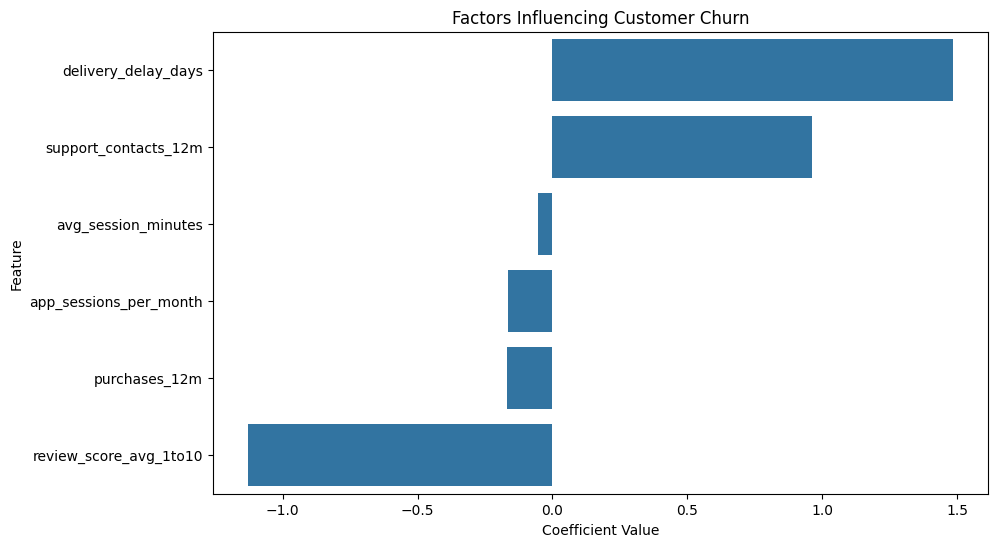

In [15]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=churn_coef,
    x="Coefficient",
    y="Variable"
)
plt.title("Factors Influencing Customer Churn")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

**Interpretation:**
- The chart prominently shows that **`delivery_delay_days` and `support_contacts_12m` are the strongest factors increasing churn risk**.
- Conversely, a **high `review_score_avg_1to10` is the most significant factor in reducing churn risk**.
- Companies should prioritize improving delivery logistics, streamlining support, and ensuring positive customer experiences to mitigate churn.

## 🚨 4. Identifying High-Value Customers at Risk

Pinpointing valuable customers who are also at high risk of churning allows for targeted and proactive retention efforts.

In [16]:
print("### High Value Customers At Risk (Top 5)")
display(critical_customers.head())

### High Value Customers At Risk (Top 5)


,customer_id,age,gender,region,primary_device,traffic_source,category_focus,annual_income_inr,membership_years,premium_member,...,review_score_avg_1to10,delivery_delay_days,support_contacts_12m,purchases_12m,average_order_value_inr,annual_revenue_inr,predicted_churn_risk,estimated_clv_inr,value_segment,churn_flag
12,C0013,39,Female,South,iOS,Organic,Beauty,965331,1.0,1,...,4.2,2,1,8,2346.63,17514.18,0.192,28727.46,High,1
19,C0020,18,Male,Metro,Android,Organic,Beauty,723082,2.4,1,...,8.1,3,3,10,2794.57,28688.60,0.176,57254.64,VIP,1
29,C0030,40,Female,South,Android,Email,Home,250000,0.9,1,...,5.7,2,0,14,2371.73,37871.86,0.152,64294.91,VIP,1
31,C0032,22,Female,West,Android,Organic,Sports,628464,1.6,1,...,5.2,3,0,9,2439.35,18282.77,0.184,32791.39,High,1
37,C0038,47,Male,East,iOS,Referral,Fashion,675962,2.5,1,...,9.0,4,1,10,2217.12,23453.46,0.164,48037.38,VIP,1


**Interpretation:**
- This table lists customers from the 'High' and 'VIP' segments who have a `predicted_churn_risk` greater than the median cutoff.
- These customers represent a critical group: they are valuable to the business but are showing signs of potential churn. Immediate, personalized intervention strategies should be developed for these individuals.

## 🎯 5. Final Business Insights & Recommendations

Based on the comprehensive analysis, here are the key takeaways and strategic recommendations tailored to each customer segment.

### 🌟 Business Insights

1.  **Value Segmentation:** Customers are effectively categorized into Low, Medium, High, and VIP groups based on their Customer Lifetime Value.
2.  **VIP Dominance:** VIP customers consistently generate the highest revenue and estimated CLV, highlighting their paramount importance.
3.  **Revenue Drivers:** Purchase frequency, pages per session, and average order value are key positive influencers of annual revenue.
4.  **Churn Influencers:** Delivery delays and high support contact frequency significantly increase churn risk, while high review scores are a strong deterrent to churn.
5.  **At-Risk Customers:** A substantial number of High and VIP customers show a high predicted churn risk, necessitating immediate attention.

### 💡 Strategic Recommendations

#### VIP Segment:
-   **Loyalty Rewards:** Implement exclusive loyalty programs and personalized offers.
-   **Premium Support:** Offer dedicated account managers or priority support channels.
-   **Relationship Management:** Focus on personalized communication and proactive engagement to foster long-term loyalty.

#### High Segment:
-   **Cross-selling & Upselling:** Introduce complementary products/services and encourage upgrades to premium offerings.
-   **Membership Upgrades:** Incentivize moving to VIP status through tailored benefits.

#### Medium Segment:
-   **Personalized Promotions:** Offer discounts or bundles based on their browsing and purchase history.
-   **Engagement Campaigns:** Run targeted campaigns to increase app sessions, pages per session, and overall interaction.

#### Low Segment:
-   **Automated Campaigns:** Utilize automated email or SMS campaigns for reminders, promotions, and re-engagement.
-   **Discount Reminders:** Offer introductory discounts or special deals to encourage initial purchases.

### 🚧 Limitation

This analysis relies on historical data and predicted churn risk. Customer preferences and market conditions can evolve, necessitating continuous monitoring and periodic re-evaluation of these insights and strategies to maintain effectiveness.